- In this notebook: Extending data set for SEA, sorting by 20-50 keV counts and taking top 100

- Extending past top 200, issues start to arise with duration function (difference btwn. data points too low for current method) and energy ranges

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [6]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [7]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [139]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(200)
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [140]:
flarelist

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,2024-05-20 05:14:40.351,15995187,409599,884735,475135,204799,247.0,37.0,...,2405200514,0.750127,X6,X25,X12,5.834281e-04,0.002534,1.198135e-03,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024052...
15798,2024-05-14T16:43:32.086,2024-05-14T17:02:16.088,2024-05-14 16:47:32.086,13148990,442367,753663,311295,155647,303.0,41.0,...,2405141647,0.754086,X4,X18,X8,4.217016e-04,0.001782,8.543020e-04,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
4360,2022-09-29T11:44:36.211,2022-09-29T12:51:48.218,2022-09-29 11:51:36.211,6411371,376831,507903,188415,77823,271.0,45.0,...,2209291151,0.798857,M7,X3,X1,7.000000e-05,0.000300,1.000000e-04,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022092...
4361,2022-09-29T11:44:32.211,2022-09-29T12:51:56.218,2022-09-29 11:57:32.212,1769471,376831,507903,188415,77823,271.0,45.0,...,2209291157,0.800781,M2,M8,M4,2.000000e-05,0.000080,4.000000e-05,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022092...
21278,2024-10-03T12:04:29.984,2024-10-03T13:15:41.992,2024-10-03 12:12:37.985,27216076,376831,622591,139263,34815,303.0,41.0,...,2410031212,0.878912,X1,X6,X3,1.490822e-04,0.000575,2.885737e-04,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024100...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4388,2022-09-29T20:08:36.264,2022-09-29T21:02:16.269,2022-09-29 20:11:20.264,1635080,278527,51199,7423,863,303.0,45.0,...,2209292011,0.821292,M2,M7,M4,2.000000e-05,0.000070,4.000000e-05,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022092...
3554,2022-09-06T10:15:08.716,2022-09-06T10:17:48.716,2022-09-06 10:16:28.716,2431,1087,2175,7423,15871,271.0,45.0,...,2209061016,0.980981,B7,C1,B9,7.000000e-07,0.000001,9.000000e-07,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022090...
3553,2022-09-06T09:58:28.715,2022-09-06T10:07:44.715,2022-09-06 10:04:12.715,2431,1087,2175,7423,15871,271.0,45.0,...,2209061004,0.982676,B7,C1,B9,7.000000e-07,0.000001,9.000000e-07,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022090...
3541,2022-09-06T08:10:44.703,2022-09-06T08:12:36.703,2022-09-06 08:11:32.703,2687,1215,2175,7423,14847,271.0,45.0,...,2209060811,0.991341,B7,C1,B10,7.000000e-07,0.000001,1.000000e-06,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022090...


In [141]:
df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1
    
    #  first_start = min(sci_query[0][n][0].datetime for n in range(len(sci_query[0])))   
    # for file in sci_query[0]:
    #     if file[0].datetime==first_start:
    #         if file[1].datetime>=t(flarelist['end_UTC'].loc[ind]):
    #             sci_files = Fido.fetch(sci_query[0][int(overlaps_ranked[0][1])])
    #             sci_data = Product(sci_files)
            
    #             sci_df = get_stix_df(sci_data, energy_ranges)
    #             df_list.append(sci_df)
    #             indices.append(ind)
    #             break
    #         else:
    #             no_file.append(i)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [143]:
# df=df_list[10]

# fig, ax = plt.subplots()
# ax.set_ylabel('ct/(keV s)')
# ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[10]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[10]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[10]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[10]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[10]).datetime.minute}")
# ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

# ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
# ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

# plt.axvline(t(flarelist['start_UTC'].iloc[10]), 0, 1, linestyle='dashed', color='yellow')
# plt.axvline(t(flarelist['end_UTC'].iloc[10]), 0, 1, linestyle='dashed', color='yellow')
# plt.axvline(t('2024-05-15T08:34:59.000'), 0, 1, linestyle='dotted', color='red')   

In [145]:
flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [146]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [256]:
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=15)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=15)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.05) & (flare_df.index<flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_start = start_df.index[0]
        end_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>-0.05) & (flare_df.index>flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_end = end_df.index[-1]
    
        estimated_starts.append(diff_estimated_start)
        estimated_ends.append(diff_estimated_end)
    
        estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()
        durations.append(estimated_duration)
    
        flare_df_50100 = flare_df[np.abs(flare_df['50.0 keV-100.0 keV'].diff())>0.02]

        if not flare_df_50100.empty:
            diff_estimated_start_50100 = flare_df_50100.index[0]
            diff_estimated_end_50100 = flare_df_50100.index[-1]
    
            estimated_starts_50100.append(diff_estimated_start_50100)
            estimated_ends_50100.append(diff_estimated_end_50100)
    
            estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
            durations_50100.append(estimated_duration_50100)
    
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [257]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

In [551]:
len(indices_refined)

97

In [555]:
flarelist.loc[indices_refined].to_csv('flares_csv.csv')

In [258]:
df_list_extrafiltered = []
for df in df_list_refined:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 105, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 105, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [259]:
df_list_full=[]
i=0
for df in df_list:
    if i not in no_file:
        df_list_full.append(df)
    i+=1

indices_full = []
i=0
for ind in indices:
    if i not in no_file:
        indices_full.append(ind)
    i+=1

In [260]:
df_list_extrafiltered_full = []
for df in df_list_full:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 105, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 105, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered_full.append(df_filtered)

In [261]:
range_x=np.arange(0, 100, 1)
locs=list(set(range_x)-set(checklist2))
len(locs)

56

In [462]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [268]:
#times_25_50_full, times_50_100_full = flare_durations(df_list_extrafiltered_full, indices_full)

In [463]:
starts=times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

In [468]:
len(np.where(np.array(durations)>2000)[0])

71

In [467]:
len(np.where(np.array(durations)>3600)[0])

49

In [308]:
for i in range(len(durations)):
    if durations[i]>2000:
        durations[i]=2000

In [309]:
np.max(durations)

np.float64(2000.0)

In [184]:
starts_full =times_25_50_full[0]
ends_full = times_25_50_full[1]
durations_full = times_25_50_full[2]

In [160]:
max(durations)

8686.1

In [419]:
resampled_df_list = []
i=0
for df in df_list_refined:
    df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [242]:
resampled_df_list_full = []
i=0
for df in df_list_full:
    df_x = df.truncate(starts_full[i], starts_full[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df_x.resample('1s').mean()
    # resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    # resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_full.append(resampled_df)
    i+=1

In [420]:
normalised_df_list = []
for df in resampled_df_list:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list.append(normalised_df)

In [247]:
normalised_df_list_full = []
for df in resampled_df_list_full:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_full.append(normalised_df)

In [421]:
timeshifted_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, max(durations))
    timeshifted_df_list.append(timeshifted_df)
    i+=1

In [422]:
timeshifted_df_list_full = []
i=0
for df in normalised_df_list_full:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts_full[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, max(durations))
    timeshifted_df_list_full.append(timeshifted_df)
    i+=1

In [487]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list), axis=1)
concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list), axis=1)
averaged_shape_flare_2550 = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100 = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [537]:
std_2550_mean = concat_band1.std(axis=1)
std_50100_mean = concat_band2.std(axis=1)

upperlim_2550 = averaged_shape_flare_2550['25.0 keV-50.0 keV']+std_2550_mean
lowerlim_2550 = averaged_shape_flare_2550['25.0 keV-50.0 keV']-std_2550_mean

for i in np.arange(0, 2001, 1):
    if lowerlim_2550.iloc[i]<0:
        lowerlim_2550.iloc[i] = 0

upperlim_50100 = averaged_shape_flare_50100['50.0 keV-100.0 keV']+std_50100_mean
lowerlim_50100 = averaged_shape_flare_50100['50.0 keV-100.0 keV']-std_2550_mean

for i in np.arange(0, 2001, 1):
    if lowerlim_50100.iloc[i]<0:
        lowerlim_50100.iloc[i] = 0

In [538]:
# marking where less than ~half of flares are contributing

n = concat_band1.notna().sum(axis=1)
print(concat_band1.shape, n.max(), n.median())

(2001, 97) 97 97.0


In [539]:
np.where(n<97)

(array([1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
        1994, 1995, 1996, 1997, 1998, 1999, 2000]),)

In [540]:
np.min(durations)

np.float64(1054.0)

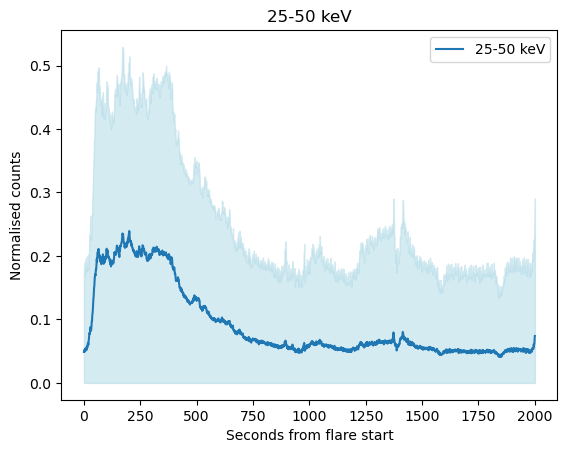

In [541]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
#plt.legend()
plt.title('25-50 keV')
ax.legend()

ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
    
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/200_top_counts_2550.png", bbox_inches='tight')

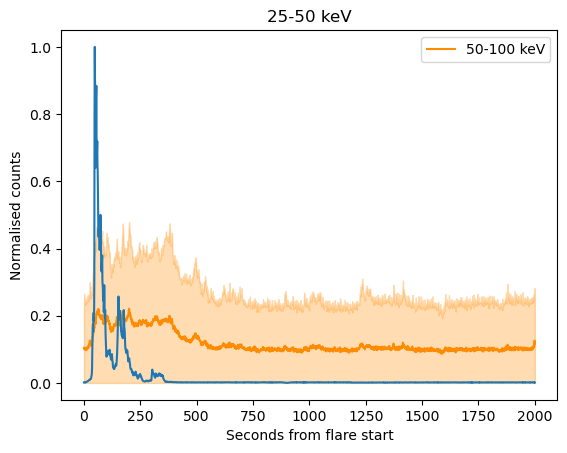

In [543]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[0].index, timeshifted_df_list[0]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

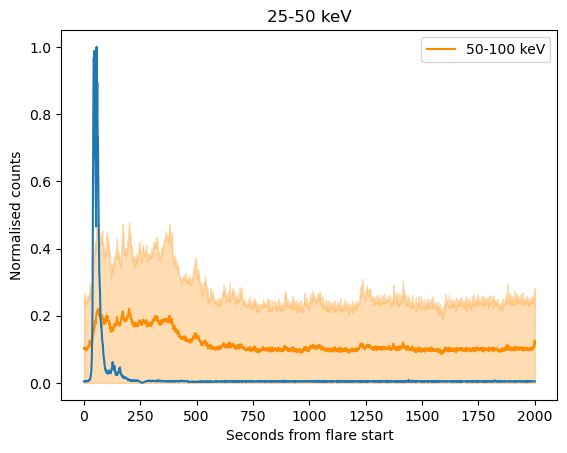

In [544]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[1].index, timeshifted_df_list[1]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

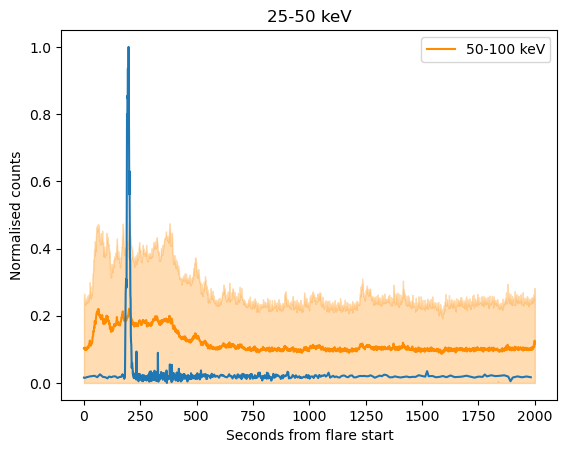

In [545]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[50].index, timeshifted_df_list[50]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

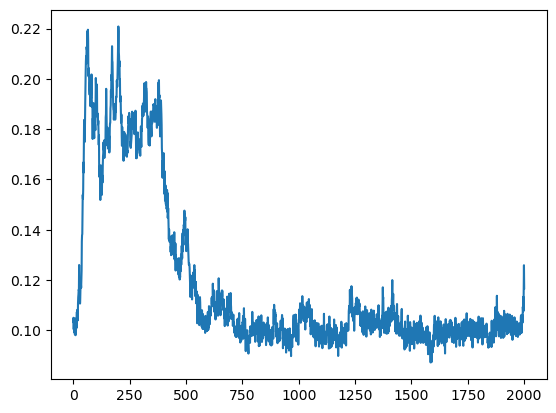

In [317]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'])

In [488]:
median_shape_flare_2550 = pd.DataFrame(concat_band1.median(axis=1), columns=['25.0 keV-50.0 keV'])
median_shape_flare_50100 = pd.DataFrame(concat_band2.median(axis=1), columns=['50.0 keV-100.0 keV'])

<Axes: >

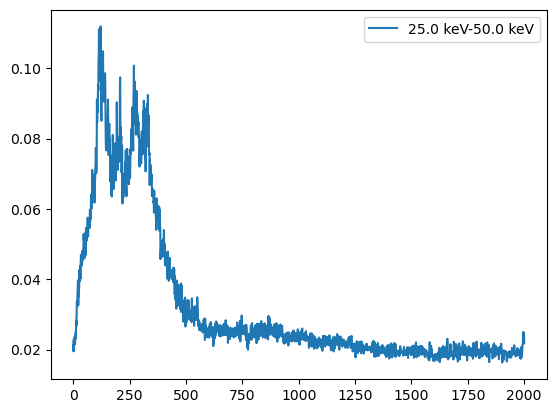

In [489]:
median_shape_flare_2550.plot()

In [429]:
resampled_df_list_peaks = []
i=0
for df in df_list_refined:
    #df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)
    i+=1

normalised_df_list_peaks = []
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)

In [646]:
timeshifted_peaks_df_list = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['25.0 keV-50.0 keV'] == np.max(df['25.0 keV-50.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list.append(timeshifted_df)
    i+=1

In [647]:
timeshifted_peaks_df_list_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['50.0 keV-100.0 keV'] == np.max(df['50.0 keV-100.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list_50100.append(timeshifted_df)
    i+=1

In [653]:
ts_peaks_list = []
for df in timeshifted_peaks_df_list:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list.append(df)

In [654]:
ts_peaks_list_50100 = []
for df in timeshifted_peaks_df_list_50100:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list_50100.append(df)

In [655]:
concat_band1_peaks = pd.concat((df['25.0 keV-50.0 keV'] for df in ts_peaks_list), axis=1)
concat_band2_peaks = pd.concat((df['50.0 keV-100.0 keV'] for df in ts_peaks_list_50100), axis=1)
averaged_shape_flare_2550_peaks = pd.DataFrame(concat_band1_peaks.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_peaks = pd.DataFrame(concat_band2_peaks.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [433]:
len(timeshifted_peaks_df_list[2]['25.0 keV-50.0 keV'])

1057

In [434]:
i=0
for df in timeshifted_peaks_df_list:
    if len(df['25.0 keV-50.0 keV'])>=2000:
        print(i)
    i+=1

In [435]:
lengths=[]
for df in timeshifted_peaks_df_list:
    lengths.append(len(df['25.0 keV-50.0 keV']))
np.max(lengths)

np.int64(1985)

In [514]:
concat_band1_peaks

,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,...,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV
-1000,0.001934,0.003945,0.003945,0.004491,0.005556,0.004189,0.004189,0.005556,0.003091,0.006878,...,0.023358,0.011758,0.095708,0.057966,0.095708,0.069135,0.082330,0.067146,0.026301,0.093875
-999,0.001932,0.003878,0.003878,0.004324,0.005554,0.004187,0.004187,0.005554,0.003129,0.008135,...,0.023405,0.011748,0.096119,0.058648,0.096119,0.092335,0.082445,0.070902,0.026233,0.092195
-998,0.001934,0.003811,0.003811,0.004212,0.005552,0.004186,0.004186,0.005552,0.003166,0.007669,...,0.023452,0.011738,0.096531,0.055763,0.096531,0.078131,0.082560,0.077005,0.026165,0.092934
-997,0.001935,0.003810,0.003810,0.003403,0.005550,0.004455,0.004455,0.005550,0.003198,0.007158,...,0.023500,0.011728,0.096170,0.052879,0.096170,0.072449,0.082675,0.079822,0.026096,0.093672
-996,0.001937,0.003809,0.003809,0.004408,0.005548,0.004206,0.004206,0.005548,0.003229,0.006320,...,0.023547,0.011718,0.095809,0.049994,0.095809,0.073396,0.082790,0.071841,0.026028,0.094411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.002888,0.003785,0.003785,0.002761,0.004374,0.003827,0.003827,0.004374,0.009115,0.020696,...,0.024515,0.012660,0.091425,0.055081,0.091425,0.069135,0.081368,0.065737,0.026180,0.084795
996,0.003480,0.003865,0.003865,0.002091,0.005756,0.003048,0.003048,0.005756,0.009518,0.020091,...,0.024447,0.012883,0.091453,0.056130,0.091453,0.077184,0.081162,0.069493,0.026191,0.087881
997,0.003409,0.003624,0.003624,0.002007,0.005814,0.003914,0.003914,0.005814,0.010070,0.021626,...,0.024379,0.012660,0.091481,0.056760,0.091481,0.070082,0.080956,0.067615,0.026201,0.086338
998,0.003101,0.003644,0.003644,0.002538,0.004580,0.002904,0.002904,0.004580,0.009815,0.020603,...,0.024310,0.012437,0.091508,0.057389,0.091508,0.057771,0.081395,0.071371,0.026212,0.099199


In [656]:
std_2550_peaks = concat_band1_peaks.std(axis=1)
std_50100_peaks = concat_band2_peaks.std(axis=1)

upperlim_2550_peaks = averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']+std_2550_peaks
lowerlim_2550_peaks = averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']-std_2550_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_2550_peaks.iloc[i]<0:
        lowerlim_2550_peaks.iloc[i] = 0

upperlim_50100_peaks = averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV']+std_50100_peaks
lowerlim_50100_peaks = averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV']-std_50100_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_50100_peaks.iloc[i]<0:
        lowerlim_50100_peaks.iloc[i] = 0

In [637]:
avg_peaks_filtered = pd.concat((averaged_shape_flare_2550_peaks, averaged_shape_flare_50100_peaks), axis=1)

# avg_peaks_filtered = avg_flare_peaks.copy()

# filtered_2550 = savgol_filter(avg_flare_peaks['25.0 keV-50.0 keV'], window_length = 55, polyorder=2)
# filtered_50100 = savgol_filter(avg_flare_peaks['50.0 keV-100.0 keV'], window_length = 55, polyorder=2)

# avg_peaks_filtered['25.0 keV-50.0 keV'] = filtered_2550
# avg_peaks_filtered['50.0 keV-100.0 keV'] = filtered_50100


In [638]:
half_max = 0.5*np.max(avg_peaks_filtered['25.0 keV-50.0 keV'])
half_max_loc = avg_peaks_filtered.index[avg_peaks_filtered['25.0 keV-50.0 keV']>= half_max][0]

over_half = np.where(avg_peaks_filtered['25.0 keV-50.0 keV']>half_max)
end_point = avg_peaks_filtered.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.int64(35)

In [660]:
half_max = 0.5*np.max(avg_peaks_filtered['50.0 keV-100.0 keV'])
half_max_loc = avg_peaks_filtered.index[avg_peaks_filtered['50.0 keV-100.0 keV']>= half_max][0]

over_half = np.where(avg_peaks_filtered['50.0 keV-100.0 keV']>half_max)
end_point = avg_peaks_filtered.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.int64(21)

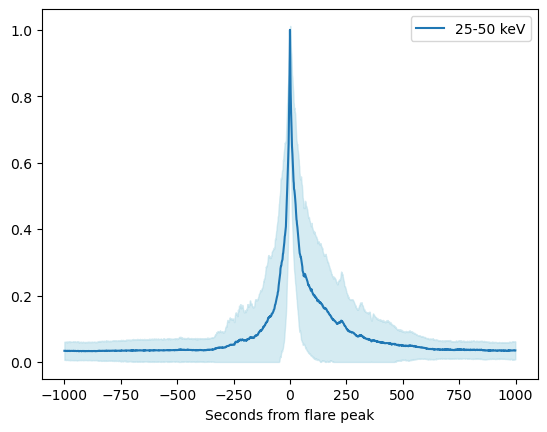

In [526]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_peaks.index, averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(averaged_shape_flare_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_8/figs_for_presentation/normalised_peak_2550.png", bbox_inches='tight')

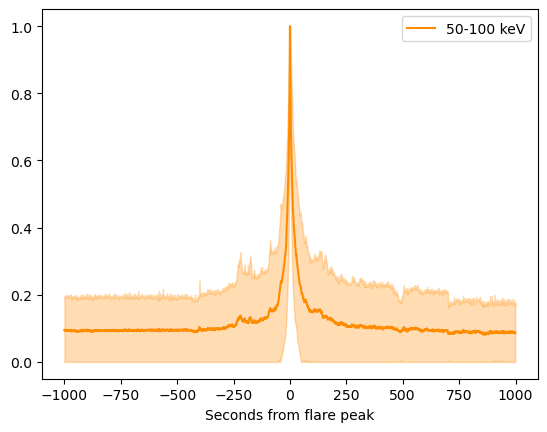

In [658]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100_peaks.index, averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
ax.fill_between(averaged_shape_flare_50100_peaks.index, lowerlim_50100_peaks, upperlim_50100_peaks, color='darkorange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_8/figs_for_presentation/normalised_peak_50100.png", bbox_inches='tight')

In [195]:
len(df_list_refined)

97

In [236]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list_full), axis=1)
concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_full), axis=1)
averaged_shape_flare_2550_full = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_full = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])

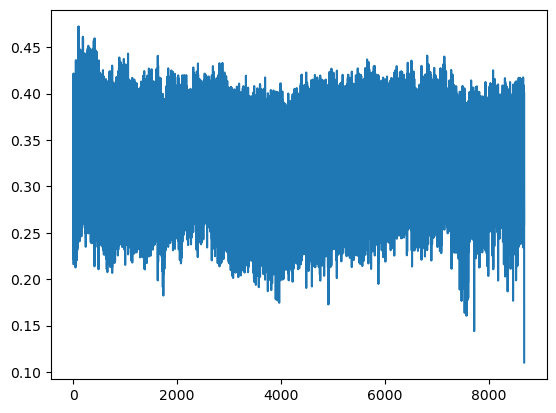

In [237]:
plt.plot(averaged_shape_flare_2550_full.index, averaged_shape_flare_2550_full['25.0 keV-50.0 keV'])

In [207]:
i=0
track=0
for i in range(len(df_list)):
    if i not in no_file:
        df = df_list[i]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(t(flarelist['start_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
        plt.axvline(t(flarelist['end_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/test1/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_22000\70073771.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [271]:
i=0
track=0
for i in range(len(df_list)):
    if i not in checklist2:
        df = df_list_refined[track]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
        start = t(times_25_50[0][track])
        end = t(times_25_50[1][track])
        
        df = df.truncate(start - dt.timedelta(minutes=30), end + dt.timedelta(minutes=30))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(start, 0, 1, linestyle='dashed', color='palevioletred')
        plt.axvline(end, 0, 1, linestyle='dashed', color='palevioletred')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/2550_counts_durations/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_22000\2093946754.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


- Duration normalised:

In [332]:
timeshifted_df_list_durations = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts[i])).round('1s')
    end = pd.to_datetime(t(ends[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()

    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, durations[i])
    timeshifted_df.index = timeshifted_df.index/durations[i]
    timeshifted_df_list_durations.append(timeshifted_df)
    i+=1

In [333]:

resampled_ind = np.linspace(0, 1, 1000)

resampled_duration_norm = []
for df in timeshifted_df_list_durations:
    resampled_df = df.reindex(df.index.union(resampled_ind)).interpolate('linear').loc[resampled_ind]
    resampled_duration_norm.append(resampled_df)

In [334]:
concat_band1_durations = pd.concat((df['25.0 keV-50.0 keV'] for df in resampled_duration_norm), axis=1)
averaged_shape_flare_2550_durations = pd.DataFrame(concat_band1_durations.mean(axis=1), columns=['25.0 keV-50.0 keV'])

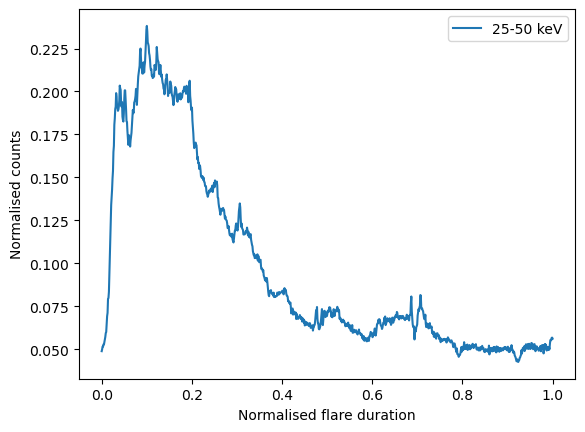

In [335]:
plt.plot(averaged_shape_flare_2550_durations.index, averaged_shape_flare_2550_durations['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Normalised flare duration')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/duration_normalised_2550.png", bbox_inches='tight')

In [469]:
peak_ratios = []
durations_for_plot = []
i=0
for df in resampled_df_list:
    df = df.truncate(starts[i], ends[i])
    peak_2550 = np.max(df['25.0 keV-50.0 keV'])
    peak_50100 = np.max(df['50.0 keV-100.0 keV'])
    peak_ratio = peak_50100/peak_2550
    if peak_ratio<1:
        peak_ratios.append(peak_ratio)
        if durations[i]<=3600:
            durations_for_plot.append(durations[i])
        else:
            durations_for_plot.append(3600)
    i+=1




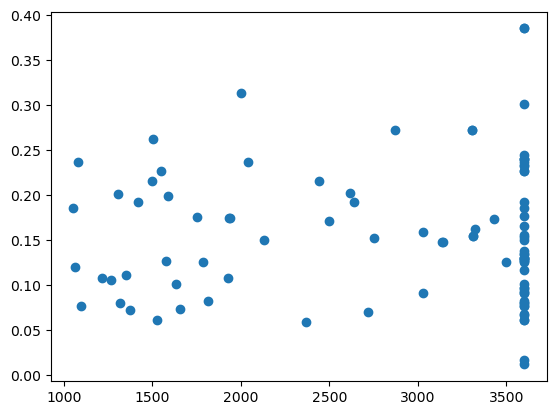

In [470]:
plt.scatter(durations_for_plot, peak_ratios)

In [498]:
len(flarelist.index)

200

In [512]:
test = flarelist.copy()
test = test.set_index(test.index).reindex(np.arange(0, 201, 1))

# test = test[test['att_in']==True]

len(set(test.index).difference(set(locs)))

145

In [511]:
test.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       191, 192, 193, 194, 195, 196, 197, 198, 199, 200],
      dtype='int64', length=201)

In [569]:
df=df_list_extrafiltered[0]
df.index[np.where(df['25.0 keV-50.0 keV']==np.max(df['25.0 keV-50.0 keV']))[0][0]]

Timestamp('2024-05-14 16:45:03.071000')

In [572]:
flarelist['start_UTC'].loc[indices_refined[i]]

'2024-05-14T16:43:32.086'

In [582]:
i

8

In [608]:
threshold_starts = []
threshold_ends = []
durations = []
i=0
for df in df_list_extrafiltered:
    start = parse_time(flarelist['start_UTC'].loc[indices_refined[i]]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist['end_UTC'].loc[indices_refined[i]]).datetime  + dt.timedelta(minutes=10)

    df.index = parse_time(df.index).datetime 
    df = df.truncate(start, end)
        
    r = flarelist['solo_position_AU_distance'].loc[indices_refined[i]]

    peak_loc = df.index[np.where(df['25.0 keV-50.0 keV']==np.max(df['25.0 keV-50.0 keV']))[0][0]]

    flare = df[df['25.0 keV-50.0 keV']>10/r**2]
    if not flare.empty:
        tstart = flare.index[0]
        if not df[(df['25.0 keV-50.0 keV']<10/r**2) & (df.index>peak_loc)].empty:
            tend = df[(df['25.0 keV-50.0 keV']<10/r**2) & (df.index>peak_loc)].index[0]
            duration = tend - tstart
            duration = duration.total_seconds()
        else:
            tend=np.nan
            tstart=np.nan
            duration = np.nan
    else:
        tstart = np.nan
        tend=np.nan
        duration = np.nan

    threshold_starts.append(tstart)
    threshold_ends.append(tend)
    durations.append(duration)

    i+=1

In [612]:
ds = []
for dur in durations:
    if pd.notna(dur):
        ds.append(dur)

In [613]:
np.max(ds)

np.float64(1117.0)

In [620]:
timeshifted_df_list_thresholds = []
i=0
for df in normalised_df_list:
    if pd.notna(threshold_starts[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start_time = threshold_starts[i]
        start_time = pd.to_datetime(t(start_time)).round('1s')

        end_time = threshold_ends[i]
        end_time = pd.to_datetime(t(end_time)).round('1s')
        #
    
        total_start_time = (start_time - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_start_time
        timeshifted_df = timeshifted_df.truncate(0, np.max(ds))
        timeshifted_df_list_thresholds.append(timeshifted_df)
    i+=1

In [621]:
concat_band1_th = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list_thresholds), axis=1)
concat_band2_th = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_thresholds), axis=1)
averaged_shape_flare_2550_th = pd.DataFrame(concat_band1_th.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_th = pd.DataFrame(concat_band2_th.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [622]:
len(upperlim_2550_th)

1990

In [623]:
std_2550_mean_th = concat_band1_th.std(axis=1)
std_50100_mean_th = concat_band2_th.std(axis=1)

upperlim_2550_th = averaged_shape_flare_2550_th['25.0 keV-50.0 keV']+std_2550_mean_th
lowerlim_2550_th = averaged_shape_flare_2550_th['25.0 keV-50.0 keV']-std_2550_mean_th

for i in np.arange(0, len(upperlim_2550_th), 1):
    if lowerlim_2550_th.iloc[i]<0:
        lowerlim_2550_th.iloc[i] = 0

upperlim_50100_th = averaged_shape_flare_50100_th['50.0 keV-100.0 keV']+std_50100_mean_th
lowerlim_50100_th = averaged_shape_flare_50100_th['50.0 keV-100.0 keV']-std_2550_mean_th

for i in np.arange(0, len(upperlim_2550_th), 1):
    if lowerlim_50100_th.iloc[i]<0:
        lowerlim_50100_th.iloc[i] = 0

In [626]:
n = concat_band1.notna().sum(axis=1)
print(concat_band1.shape, n.max(), n.median())

(2001, 97) 97 97.0


In [629]:
np.where(n<50)

(array([2000]),)

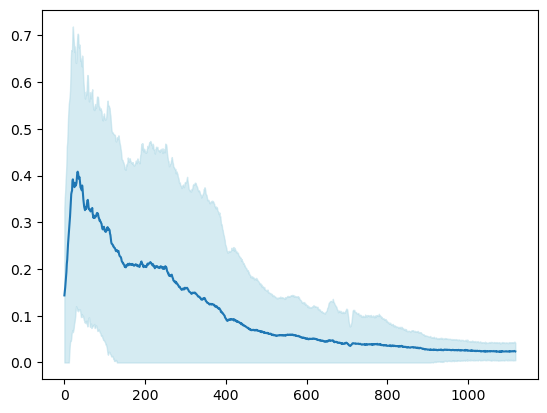

In [639]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_th.index, averaged_shape_flare_2550_th['25.0 keV-50.0 keV'])
ax.fill_between(averaged_shape_flare_2550_th.index, lowerlim_2550_th, upperlim_2550_th, color = 'lightblue', alpha=0.5)

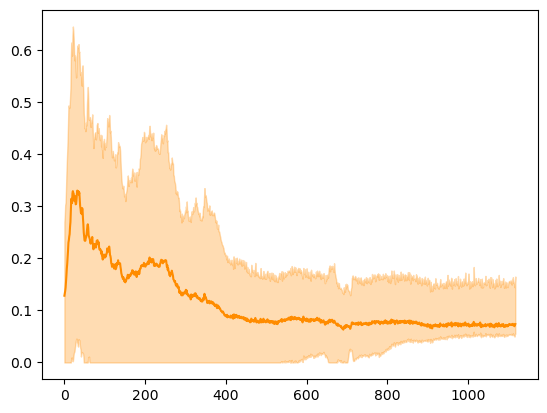

In [631]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100_th.index, averaged_shape_flare_50100_th['50.0 keV-100.0 keV'], color='darkorange')
ax.fill_between(averaged_shape_flare_50100_th.index, lowerlim_50100_th, upperlim_50100_th, color = 'darkorange', alpha=0.3)

In [684]:
fwhm_list = []
i=0
for df in df_list_refined:
    df = df.truncate(t(starts[i])-dt.timedelta(minutes=5), t(ends[i])+dt.timedelta(minutes=5))

    half_max = 0.5*np.max(df['25.0 keV-50.0 keV'])
    half_max_loc = df.index[df['25.0 keV-50.0 keV']>= half_max][0]
    
    over_half = np.where(df['25.0 keV-50.0 keV']>half_max)
    end_point = df.index[over_half[0][-1]]
    
    fwhm = (end_point-half_max_loc)
    fwhm = fwhm.total_seconds()
    fwhm_list.append(fwhm)
    i+=1

In [686]:
np.mean(fwhm_list)

np.float64(94.03350515463917)

In [687]:
fwhm_list_50100 = []
i=0
for df in df_list_refined:
    df = df.truncate(t(starts[i])-dt.timedelta(minutes=5), t(ends[i])+dt.timedelta(minutes=5))

    if np.max(df['50.0 keV-100.0 keV'])<3:
        fwhm_list_50100.append(np.nan)
    else:
        half_max = 0.5*np.max(df['50.0 keV-100.0 keV'])
        half_max_loc = df.index[df['50.0 keV-100.0 keV']>= half_max][0]
        
        over_half = np.where(df['50.0 keV-100.0 keV']>half_max)
        end_point = df.index[over_half[0][-1]]
        
        fwhm = (end_point-half_max_loc)
        fwhm = fwhm.total_seconds()
        if fwhm>fwhm_list[i]:
            fwhm = fwhm_list[i]
        fwhm_list_50100.append(fwhm)
    i+=1

In [688]:
np.nanmean(fwhm_list_50100)

np.float64(65.73041237113401)

In [ ]:
label=0
i=0
half_max_points = []
half_max_vals = []
end_points = []
end_point_vals = []
fwhm_list = []
half_max_points_50100 = []
half_max_vals_50100 = []
end_points_50100 = []
end_point_vals_50100 = []
fwhm_list_50100 = []
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        tstart = filtered_stats_df['start_time'].iloc[label]
        tend = filtered_stats_df['end_time'].iloc[label]
        tpeak = filtered_stats_df['peak_time'].iloc[label]

        r = top100['solo_position_AU_distance'].loc[ind]
        max_counts = (filtered_stats_df['peak_counts'].iloc[label])*r**2

        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        half_max = 0.5*max_counts
        half_max_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] >= half_max][0]
        half_max_points.append(half_max_loc)
        half_max_vals.append(half_max)

        over_half = np.where(plot_df['25.0 keV-50.0 keV']>half_max)
        end_point = plot_df.index[over_half[0][-1]]
        end_points.append(end_point)
        end_point_vals.append(plot_df['25.0 keV-50.0 keV'].iloc[over_half[0][-1]])

        # rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
        # decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])
        
        # durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
        # durations_50_100 = durations_50_100.dt.total_seconds()

        fwhm = (t(end_point)-t(half_max_loc))
            #.total_seconds()
        fwhm_list.append(fwhm)

        filtered_stats_df.loc[label, 'FWHM (25-50 keV)'] = fwhm.total_seconds()

        if pd.notna(filtered_stats_df['start_time (50-100 keV)'].iloc[label]):
            max_counts_50100 = (filtered_stats_df['peak_counts (50-100 keV)'].iloc[label])*r**2
    
            half_max_50100 = 0.5*max_counts_50100
            half_max_loc_50100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] >= half_max_50100][0]
            half_max_points_50100.append(half_max_loc_50100)
            half_max_vals_50100.append(half_max_50100)
    
            over_half_50100 = np.where(plot_df['50.0 keV-100.0 keV']>half_max_50100)
            end_point_50100 = plot_df.index[over_half_50100[0][-1]]
            end_points_50100.append(end_point_50100)
            end_point_vals_50100.append(plot_df['50.0 keV-100.0 keV'].iloc[over_half_50100[0][-1]])
            
            fwhm_50100 = (t(end_point_50100)-t(half_max_loc_50100))
                #.total_seconds()
            fwhm_list_50100.append(fwhm_50100)

            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = fwhm_50100.total_seconds()

        else:
            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = np.nan
            fwhm_list_50100.append(np.nan)
            half_max_vals_50100.append(np.nan)
            half_max_points_50100.append(np.nan)
            end_points_50100.append(np.nan)
            end_point_vals_50100.append(np.nan)
            
        label+=1
    i+=1